# Лабораторная работа 2
## Вариант 11

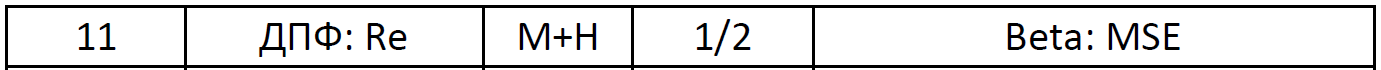

- practical-textbook: str 67-80
- theoretical-textbook: str 73-87 (вроде)

In [269]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [270]:
def calc_psnr(a: np.ndarray, b: np.ndarray) -> float:
    a_f = a.astype(np.float64)
    b_f = b.astype(np.float64)
    mse = np.mean((a_f - b_f) ** 2)
    if mse == 0:
        return float("inf")
    return 10.0 * np.log10((255.0 ** 2) / mse)

In [271]:
def generate_omega(length: int, seed: int = 42, mean: float = 0.0, std: float = 1.0) -> np.ndarray:
    np.random.seed(seed)
    omega = np.random.normal(loc=mean, scale=std, size=length)
    return omega.astype(np.float64)

In [272]:
def fft2_real(container: np.ndarray) -> np.ndarray:
    F = np.fft.fft2(container)
    return np.real(F), F

In [273]:
omega_length = 1024
omega = generate_omega(length=omega_length, seed=11)

print(f'Длина вектора Омега: {len(omega)}')
print(f'Среднее: {omega.mean():.4f}, Отклонение: {omega.std():.4f}')

Длина вектора Омега: 1024
Среднее: -0.0039, Отклонение: 1.0163


Контейнер: (816, 736), dtype=float64, min/max=0.0/222.0
Дейстивтльная часть спекта Re(F): (816, 736), min/max=-2363377.542/81898298.000


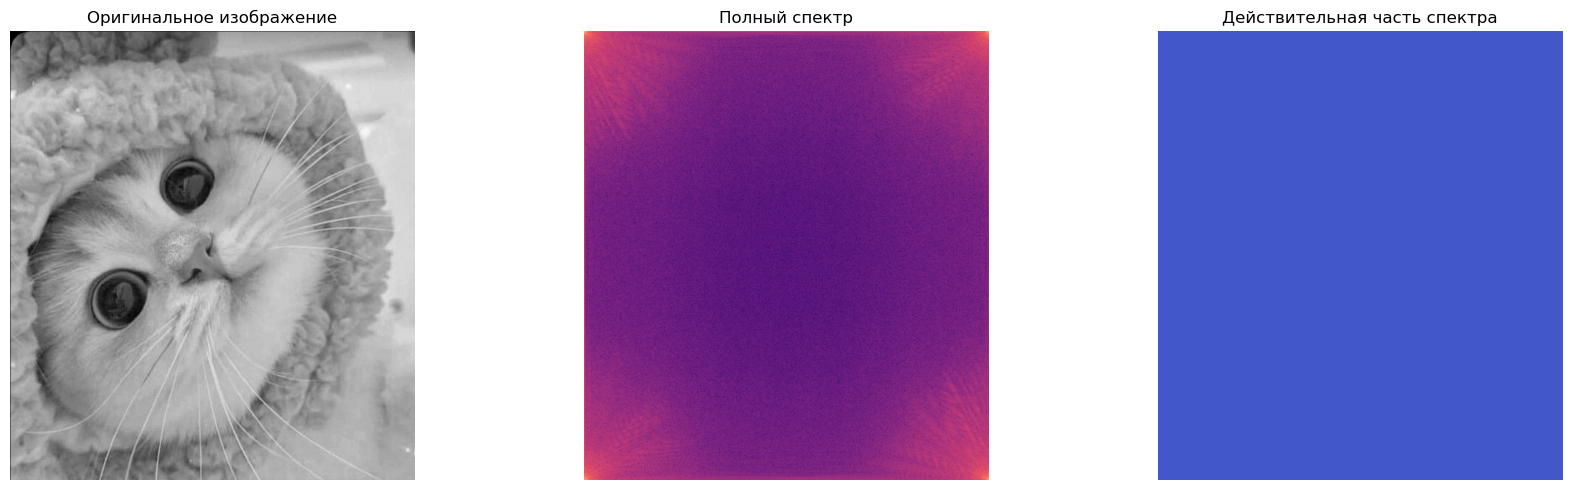

In [274]:
container_path = 'cat.jpg'
container = np.array(Image.open(container_path).convert('L'), dtype=np.float64)
features, F = fft2_real(container)

magnitude_log = np.log1p(np.abs(F))

print(f'Контейнер: {container.shape}, dtype={container.dtype}, min/max={container.min():.1f}/{container.max():.1f}')
print(f'Дейстивтльная часть спекта Re(F): {features.shape}, min/max={features.min():.3f}/{features.max():.3f}')

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].imshow(container, cmap='gray')
ax[0].set_title('Оригинальное изображение')
ax[0].axis('off')

ax[1].imshow(magnitude_log, cmap='magma')
ax[1].set_title('Полный спектр')
ax[1].axis('off')

ax[2].imshow(features, cmap='coolwarm')
ax[2].set_title('Действительная часть спектра')
ax[2].axis('off')

plt.tight_layout()
plt.show()


## Пункт 3

In [275]:
def build_dft_zone_masks(shape: tuple[int, int]):
    h, w = shape
    r, c = np.indices((h, w))

    top = r < h // 4
    bottom = r >= (3 * h) // 4
    left = c < w // 4
    right = c >= (3 * w) // 4

    L = (top & left) | (top & right) | (bottom & left) | (bottom & right)
    H = (r >= h // 4) & (r < (3 * h) // 4) & (c >= w // 4) & (c < (3 * w) // 4)
    M = ~(L | H)
    return L, M, H

In [276]:
def corner_distance_score(shape: tuple[int, int]) -> np.ndarray:
    h, w = shape
    r, c = np.indices((h, w))

    d00 = r**2 + c**2
    d01 = r**2 + (c - (w - 1))**2
    d10 = (r - (h - 1))**2 + c**2
    d11 = (r - (h - 1))**2 + (c - (w - 1))**2

    return np.minimum(np.minimum(d00, d01), np.minimum(d10, d11)).astype(np.float64)

In [277]:
def select_first_fraction_by_frequency(mask: np.ndarray, score: np.ndarray, fraction: float):
    if not (0 < fraction <= 1):
        raise ValueError('fraction must be in (0, 1]')

    flat_idx = np.flatnonzero(mask.ravel())
    score_flat = score.ravel()[flat_idx]
    order = np.argsort(score_flat, kind='mergesort')

    n_total = flat_idx.size
    n_take = max(1, int(np.floor(fraction * n_total)))
    return flat_idx[order[:n_take]], n_total, n_take

In [278]:
def get_mask(target_zone: str, L_mask, M_mask, H_mask):
    if target_zone == 'H':
        target_mask = H_mask
    elif target_zone == 'M':
        target_mask = M_mask
    elif target_zone == 'L':
        target_mask = L_mask
    elif target_zone == 'HM':
        target_mask = H_mask | M_mask
    elif target_zone == 'HL':
        target_mask = H_mask | L_mask
    elif target_zone == 'ML':
        target_mask = M_mask | L_mask
    elif target_zone == 'HML':
        target_mask = H_mask | M_mask | L_mask
    else:
        raise ValueError("target_zone incorrect")
    return target_mask

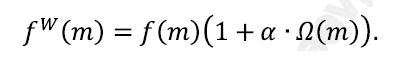

In [279]:
L_mask, M_mask, H_mask = build_dft_zone_masks(features.shape)

target_zone = 'HM'      # H, M, L, HM, ML, HL, HML
fraction = 0.5      
alpha = 1350.0          

target_mask = get_mask(target_zone, L_mask, M_mask, H_mask)

freq_score = corner_distance_score(features.shape)
embed_idx_flat, n_target_total, n_embed = select_first_fraction_by_frequency(
    mask=target_mask,
    score=freq_score,
    fraction=fraction,
)

omega = generate_omega(length=n_embed, seed=11)
features_embedded = features.copy()
features_embedded.ravel()[embed_idx_flat] += alpha * omega

F_embedded = features_embedded + 1j * np.imag(F)

print(f'Число пикселей в низких частотах: {L_mask.sum()}')
print(f'Число пикселей в средних частотах: {M_mask.sum()}')
print(f'Число пикселей в высоких частотах: {H_mask.sum()}')
print(f'Длина вектора омега: {len(omega)}')


Число пикселей в низких частотах: 150144
Число пикселей в средних частотах: 300288
Число пикселей в высоких частотах: 150144
Длина вектора омега: 225216


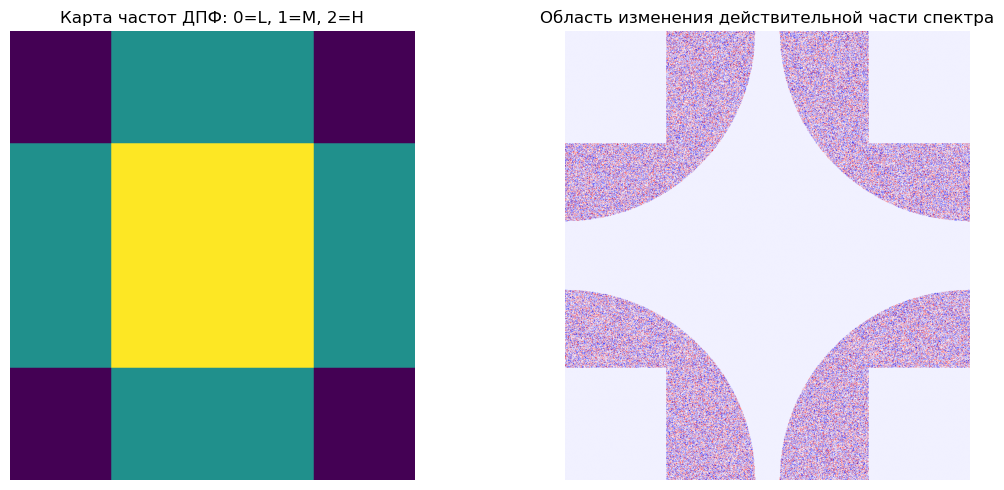

In [280]:
# Quick visualization of zones and embedding impact in feature space
zone_map = np.zeros_like(features, dtype=np.int8)
zone_map[M_mask] = 1
zone_map[H_mask] = 2

delta_features = np.zeros_like(features)
delta_features.ravel()[embed_idx_flat] = alpha * omega

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(zone_map, cmap='viridis')
ax[0].set_title('Карта частот ДПФ: 0=L, 1=M, 2=H')
ax[0].axis('off')

ax[1].imshow(delta_features, cmap='seismic')
ax[1].set_title('Область изменения действительной части спектра')
ax[1].axis('off')

plt.tight_layout()
plt.show()


## Пункт 4

In [281]:
carrier_complex = np.fft.ifft2(F_embedded)
carrier_float = np.real(carrier_complex)
carrier_uint8 = np.clip(np.rint(carrier_float), 0, 255).astype(np.uint8)

watermarked_path = f'{container_path.split('.')[0]}_watermarked.tif'
Image.fromarray(carrier_uint8).save(watermarked_path)

mse_float = np.mean((container - carrier_float) ** 2)
psnr_float = calc_psnr(container, carrier_float)

mse_uint8 = np.mean((container - carrier_uint8.astype(np.float64)) ** 2)
psnr_uint8 = calc_psnr(container, carrier_uint8)

changed_pixels = int(np.count_nonzero(container.astype(np.uint8) != carrier_uint8))
max_abs_diff_float = float(np.max(np.abs(container - carrier_float)))
imag_mean = float(np.mean(np.abs(np.imag(carrier_complex))))

print(f'Float-domain MSE: {mse_float:.8f}, PSNR: {psnr_float:.3f} dB')
print(f'Uint8-domain MSE: {mse_uint8:.8f}, PSNR: {psnr_uint8:.3f} dB')
print(f'Changed pixels after uint8 quantization: {changed_pixels}')
print(f'Max |container - carrier_float|: {max_abs_diff_float:.6f}')
print(f'Mean |Imag(ifft2)| (symmetry break indicator): {imag_mean:.6f}')

Float-domain MSE: 0.57008720, PSNR: 50.571 dB
Uint8-domain MSE: 0.65448336, PSNR: 49.972 dB
Changed pixels after uint8 quantization: 305675
Max |container - carrier_float|: 3.629407
Mean |Imag(ifft2)| (symmetry break indicator): 0.600746


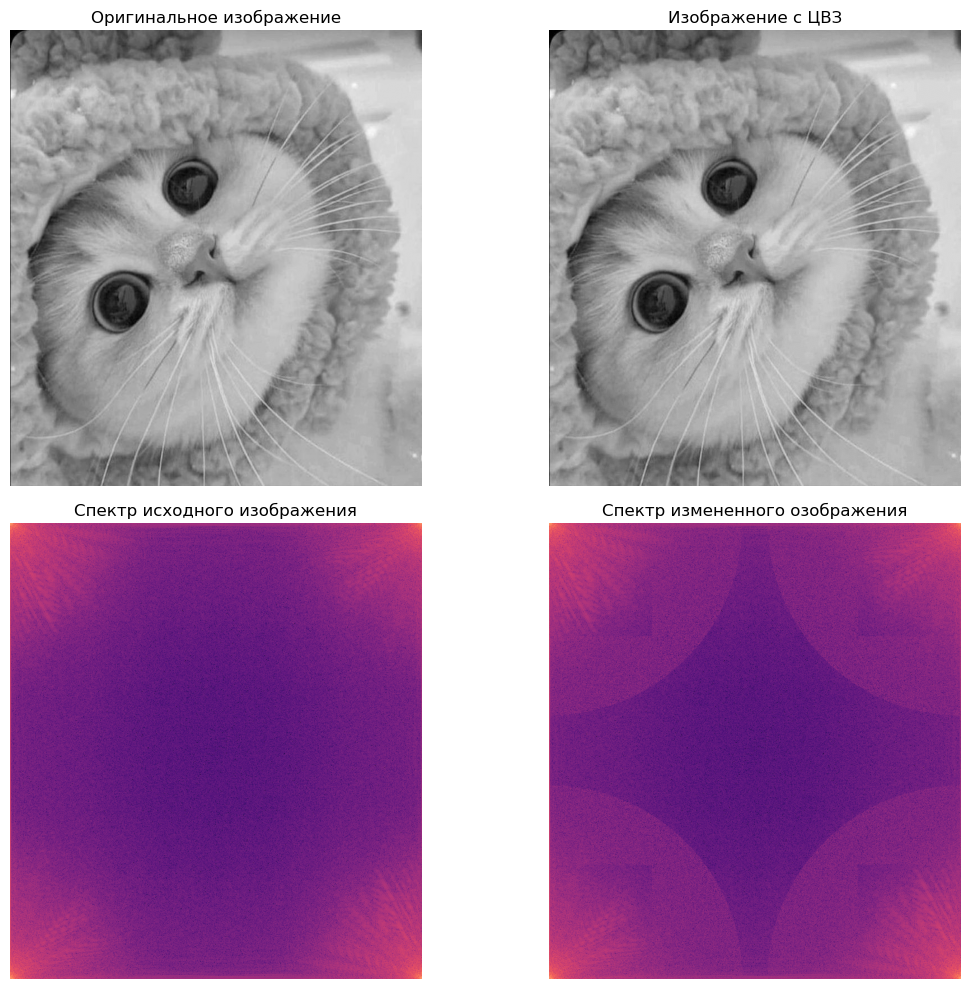

In [282]:
spec_before = np.log1p(np.abs(F))
spec_after = np.log1p(np.abs(F_embedded))

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

ax[0, 0].imshow(container, cmap='gray')
ax[0, 0].set_title('Оригинальное изображение')
ax[0, 0].axis('off')

ax[0, 1].imshow(carrier_uint8, cmap='gray')
ax[0, 1].set_title('Изображение с ЦВЗ')
ax[0, 1].axis('off')

ax[1, 0].imshow(spec_before, cmap='magma')
ax[1, 0].set_title('Спектр исходного изображения')
ax[1, 0].axis('off')

ax[1, 1].imshow(spec_after, cmap='magma')
ax[1, 1].set_title('Спектр измененного озображения')
ax[1, 1].axis('off')

plt.tight_layout()
plt.show()


## Пункты 5-7

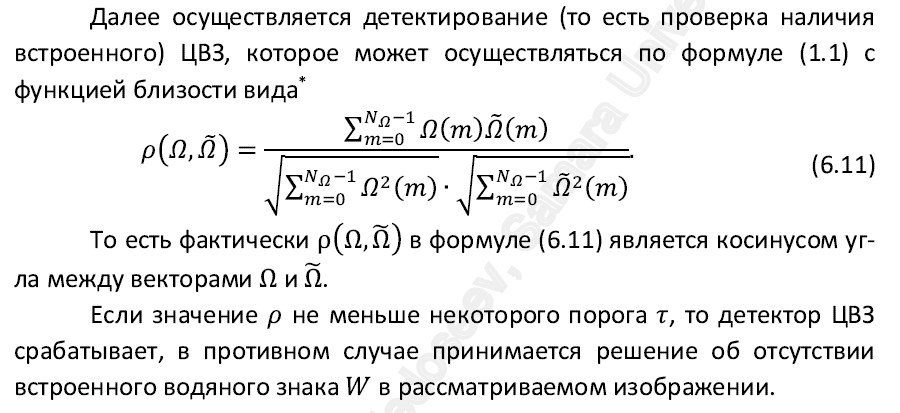

In [283]:
def similarity_rho(omega: np.ndarray, omega_tilde: np.ndarray) -> float:
    den = np.sqrt(np.sum(omega ** 2)) * np.sqrt(np.sum(omega_tilde ** 2))
    if den == 0.0:
        return 0.0
    return float(np.sum(omega * omega_tilde) / den)

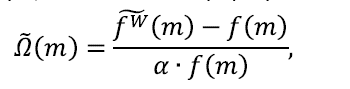

In [284]:
carrier_loaded = np.array(Image.open(watermarked_path).convert('L'), dtype=np.float64)
features_carrier, F_carrier = fft2_real(carrier_loaded)

x_orig = features.ravel()[embed_idx_flat]
x_carrier = features_carrier.ravel()[embed_idx_flat]
omega_tilde = (x_carrier - x_orig) / alpha

rho = similarity_rho(omega, omega_tilde)

print(f'Длина вектора омега: {len(omega)}')
print(f'Длина извлеченного вектора омега: {len(omega_tilde)}')
print(f'rho: {rho:.6f}')

Длина вектора омега: 225216
Длина извлеченного вектора омега: 225216
rho: 0.690725


In [285]:
def run_alpha_search(alpha_grid: np.ndarray, features_ref: np.ndarray, F_ref: np.ndarray,
                     container_ref: np.ndarray, embed_idx: np.ndarray, omega_ref: np.ndarray,
                     x_orig_ref: np.ndarray, beta_map: np.ndarray | None = None) -> list[dict]:
    results_local = []
    for alpha_candidate in alpha_grid:
        features_emb = features_ref.copy()
        features_emb.ravel()[embed_idx] += alpha_candidate * omega_ref
        F_emb = features_emb + 1j * np.imag(F_ref)

        carrier_plain = np.real(np.fft.ifft2(F_emb))
        if beta_map is None:
            carrier_float = carrier_plain
        else:
            # формула 6.15
            carrier_float = carrier_plain * beta_map + container_ref * (1.0 - beta_map)

        carrier_uint8 = np.clip(np.rint(carrier_float), 0, 255).astype(np.uint8)
        psnr_val = calc_psnr(container_ref, carrier_uint8)

        features_carrier, _ = fft2_real(carrier_uint8.astype(np.float64))
        x_carrier = features_carrier.ravel()[embed_idx]
        omega_tilde = (x_carrier - x_orig_ref) / alpha_candidate
        rho_val = similarity_rho(omega_ref, omega_tilde)

        results_local.append({
            'alpha': float(alpha_candidate),
            'psnr': float(psnr_val),
            'rho': float(rho_val),
            'carrier_uint8': carrier_uint8,
            'F': F_emb,
        })

    return results_local

In [286]:
def pick_best_under_rule(stats: list[dict], psnr_thr: float) -> tuple[dict, list[dict]]:
    feasible_local = [s for s in stats if s['psnr'] > psnr_thr]
    if len(feasible_local) == 0:
        best_local = max(stats, key=lambda s: s['psnr'])
    else:
        best_local = max(feasible_local, key=lambda s: s['rho'])
    return best_local, feasible_local

In [287]:
opt_target_zone = 'HM'   # H, M, L, HM, ML, HL, HML
opt_fraction = 0.5
psnr_threshold = 30.0
alpha_grid = np.arange(10.0, 1801.0, 10.0)

L_mask_opt, M_mask_opt, H_mask_opt = build_dft_zone_masks(features.shape)
target_mask_opt = get_mask(opt_target_zone, L_mask_opt, M_mask_opt, H_mask_opt)
freq_score_opt = corner_distance_score(features.shape)
embed_idx_opt, n_total_opt, n_embed_opt = select_first_fraction_by_frequency(
    mask=target_mask_opt,
    score=freq_score_opt,
    fraction=opt_fraction,
)

omega_opt = generate_omega(length=n_embed_opt, seed=42)
x_orig_opt = features.ravel()[embed_idx_opt]

results = run_alpha_search(
    alpha_grid=alpha_grid,
    features_ref=features,
    F_ref=F,
    container_ref=container,
    embed_idx=embed_idx_opt,
    omega_ref=omega_opt,
    x_orig_ref=x_orig_opt,
    beta_map=None,
)

best, feasible = pick_best_under_rule(results, psnr_threshold)

alpha_best = best['alpha']
psnr_best = best['psnr']
rho_best = best['rho']
F_best = best['F']

spec_best = np.log1p(np.abs(F_best))

print(f'Луччшая альфа: {alpha_best:.1f}')
print(f'Лучший PSNR: {psnr_best:.3f} dB')
print(f'Лучшее rho: {rho_best:.6f}')

Луччшая альфа: 1800.0
Лучший PSNR: 47.739 dB
Лучшее rho: 0.698385


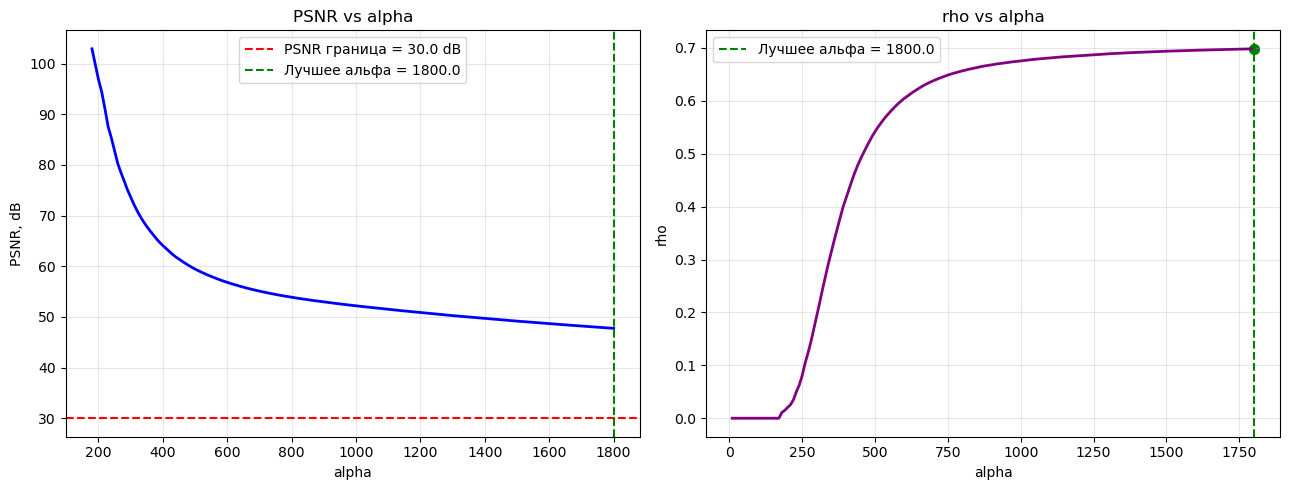

In [288]:
alphas = np.array([r['alpha'] for r in results], dtype=np.float64)
psnr_vals = np.array([r['psnr'] for r in results], dtype=np.float64)
rho_vals = np.array([r['rho'] for r in results], dtype=np.float64)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].plot(alphas, psnr_vals, color='blue', lw=2)
ax[0].axhline(psnr_threshold, color='red', ls='--', lw=1.5, label=f'PSNR граница = {psnr_threshold:.1f} dB')
ax[0].axvline(alpha_best, color='green', ls='--', lw=1.5, label=f'Лучшее альфа = {alpha_best:.1f}')
ax[0].set_title('PSNR vs alpha')
ax[0].set_xlabel('alpha')
ax[0].set_ylabel('PSNR, dB')
ax[0].grid(alpha=0.3)
ax[0].legend(loc='best')

ax[1].plot(alphas, rho_vals, color='purple', lw=2)
ax[1].axvline(alpha_best, color='green', ls='--', lw=1.5, label=f'Лучшее альфа = {alpha_best:.1f}')
ax[1].scatter([alpha_best], [rho_best], color='green', s=50)
ax[1].set_title('rho vs alpha')
ax[1].set_xlabel('alpha')
ax[1].set_ylabel('rho')
ax[1].grid(alpha=0.3)
ax[1].legend(loc='best')

plt.tight_layout()
plt.show()


## Пункт 8

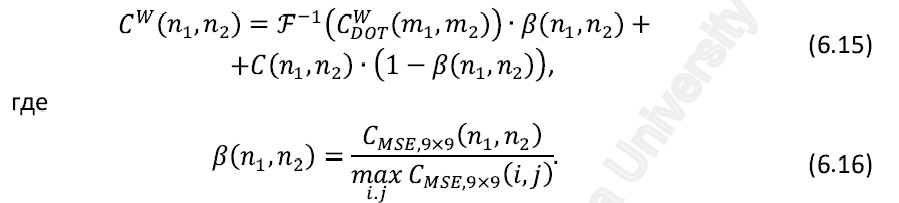

In [289]:
def beta_mse_map(container_img: np.ndarray, win: int = 9) -> np.ndarray:
    if win % 2 == 0 or win < 1:
        raise ValueError('окно должно быть нечетным положительным числом')

    img = container_img.astype(np.float64)
    pad = win // 2
    padded = np.pad(img, ((pad, pad), (pad, pad)), mode='reflect')

    ii = np.pad(padded, ((1, 0), (1, 0)), mode='constant').cumsum(axis=0).cumsum(axis=1)
    ii2 = np.pad(padded * padded, ((1, 0), (1, 0)), mode='constant').cumsum(axis=0).cumsum(axis=1)
    
    s = ii[win:, win:] - ii[:-win, win:] - ii[win:, :-win] + ii[:-win, :-win]
    s2 = ii2[win:, win:] - ii2[:-win, win:] - ii2[win:, :-win] + ii2[:-win, :-win]

    area = float(win * win)
    mean = s / area
    var = np.maximum(s2 / area - mean * mean, 0.0)
    c_mse = np.sqrt(var)

    denom = float(np.max(c_mse))
    if denom == 0.0:
        return np.zeros_like(c_mse, dtype=np.float64)
    beta = c_mse / denom
    return np.clip(beta, 0.0, 1.0)


In [290]:
v11_zone = 'HM'
v11_fraction = 0.5
v11_psnr_threshold = 30.0
v11_alpha_grid = np.arange(10.0, 1801.0, 10.0)

L8, M8, H8 = build_dft_zone_masks(features.shape)
mask8 = get_mask(v11_zone, L8, M8, H8)
score8 = corner_distance_score(features.shape)
embed_idx8, n_total8, n_embed8 = select_first_fraction_by_frequency(mask8, score8, v11_fraction)
omega8 = generate_omega(length=n_embed8, seed=43)
x_orig8 = features.ravel()[embed_idx8]

beta8 = beta_mse_map(container, win=9)

beta_stats8 = run_alpha_search(
    alpha_grid=v11_alpha_grid,
    features_ref=features,
    F_ref=F,
    container_ref=container,
    embed_idx=embed_idx8,
    omega_ref=omega8,
    x_orig_ref=x_orig8,
    beta_map=beta8,
)

best_beta8, feasible_beta8 = pick_best_under_rule(beta_stats8, v11_psnr_threshold)


alpha_best8 = best_beta8['alpha']
psnr_best8 = best_beta8['psnr']
rho_best8 = best_beta8['rho']
F_best8 = best_beta8['F']

spec_best8 = np.log1p(np.abs(F_best8))

print(f"Лучшая альфа: {alpha_best8:.1f}")
print(f"Лучший PSNR: {psnr_best8:.3f} dB")
print(f"Лучшее rho: {rho_best8:.6f}")


Лучшая альфа: 1800.0
Лучший PSNR: 64.279 dB
Лучшее rho: 0.295233


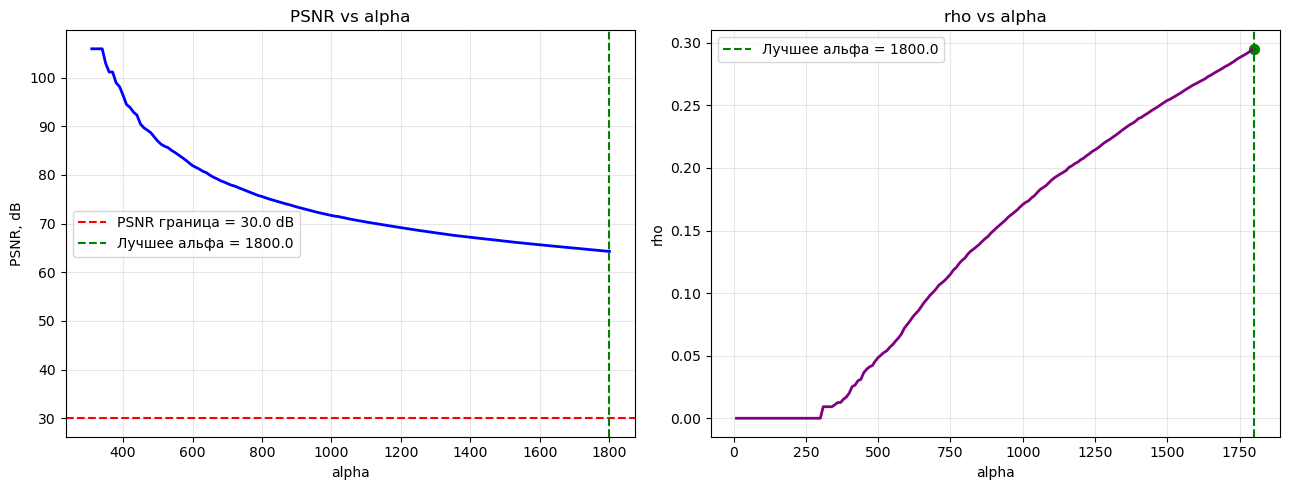

In [291]:
alphas8 = np.array([r['alpha'] for r in beta_stats8], dtype=np.float64)
psnr_vals8 = np.array([r['psnr'] for r in beta_stats8], dtype=np.float64)
rho_vals8 = np.array([r['rho'] for r in beta_stats8], dtype=np.float64)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].plot(alphas8, psnr_vals8, color='blue', lw=2)
ax[0].axhline(v11_psnr_threshold, color='red', ls='--', lw=1.5, label=f'PSNR граница = {v11_psnr_threshold:.1f} dB')
ax[0].axvline(alpha_best8, color='green', ls='--', lw=1.5, label=f"Лучшее альфа = {alpha_best8:.1f}")
ax[0].set_title('PSNR vs alpha')
ax[0].set_xlabel('alpha')
ax[0].set_ylabel('PSNR, dB')
ax[0].grid(alpha=0.3)
ax[0].legend(loc='best')

ax[1].plot(alphas8, rho_vals8, color='purple', lw=2)
ax[1].axvline(alpha_best8, color='green', ls='--', lw=1.5, label=f"Лучшее альфа = {alpha_best8:.1f}")
ax[1].scatter([alpha_best8], [rho_best8], color='green', s=50)
ax[1].set_title('rho vs alpha')
ax[1].set_xlabel('alpha')
ax[1].set_ylabel('rho')
ax[1].grid(alpha=0.3)
ax[1].legend(loc='best')

plt.tight_layout()
plt.show()


Лучшие результаты шага 7:
	alpha = 1800.0
	PSNR  = 47.739 dB
	rho   = 0.698385

Лучшие результаты шага 8 (Beta-MSE):
	alpha = 1800.0
	PSNR  = 64.279 dB
	rho   = 0.295233


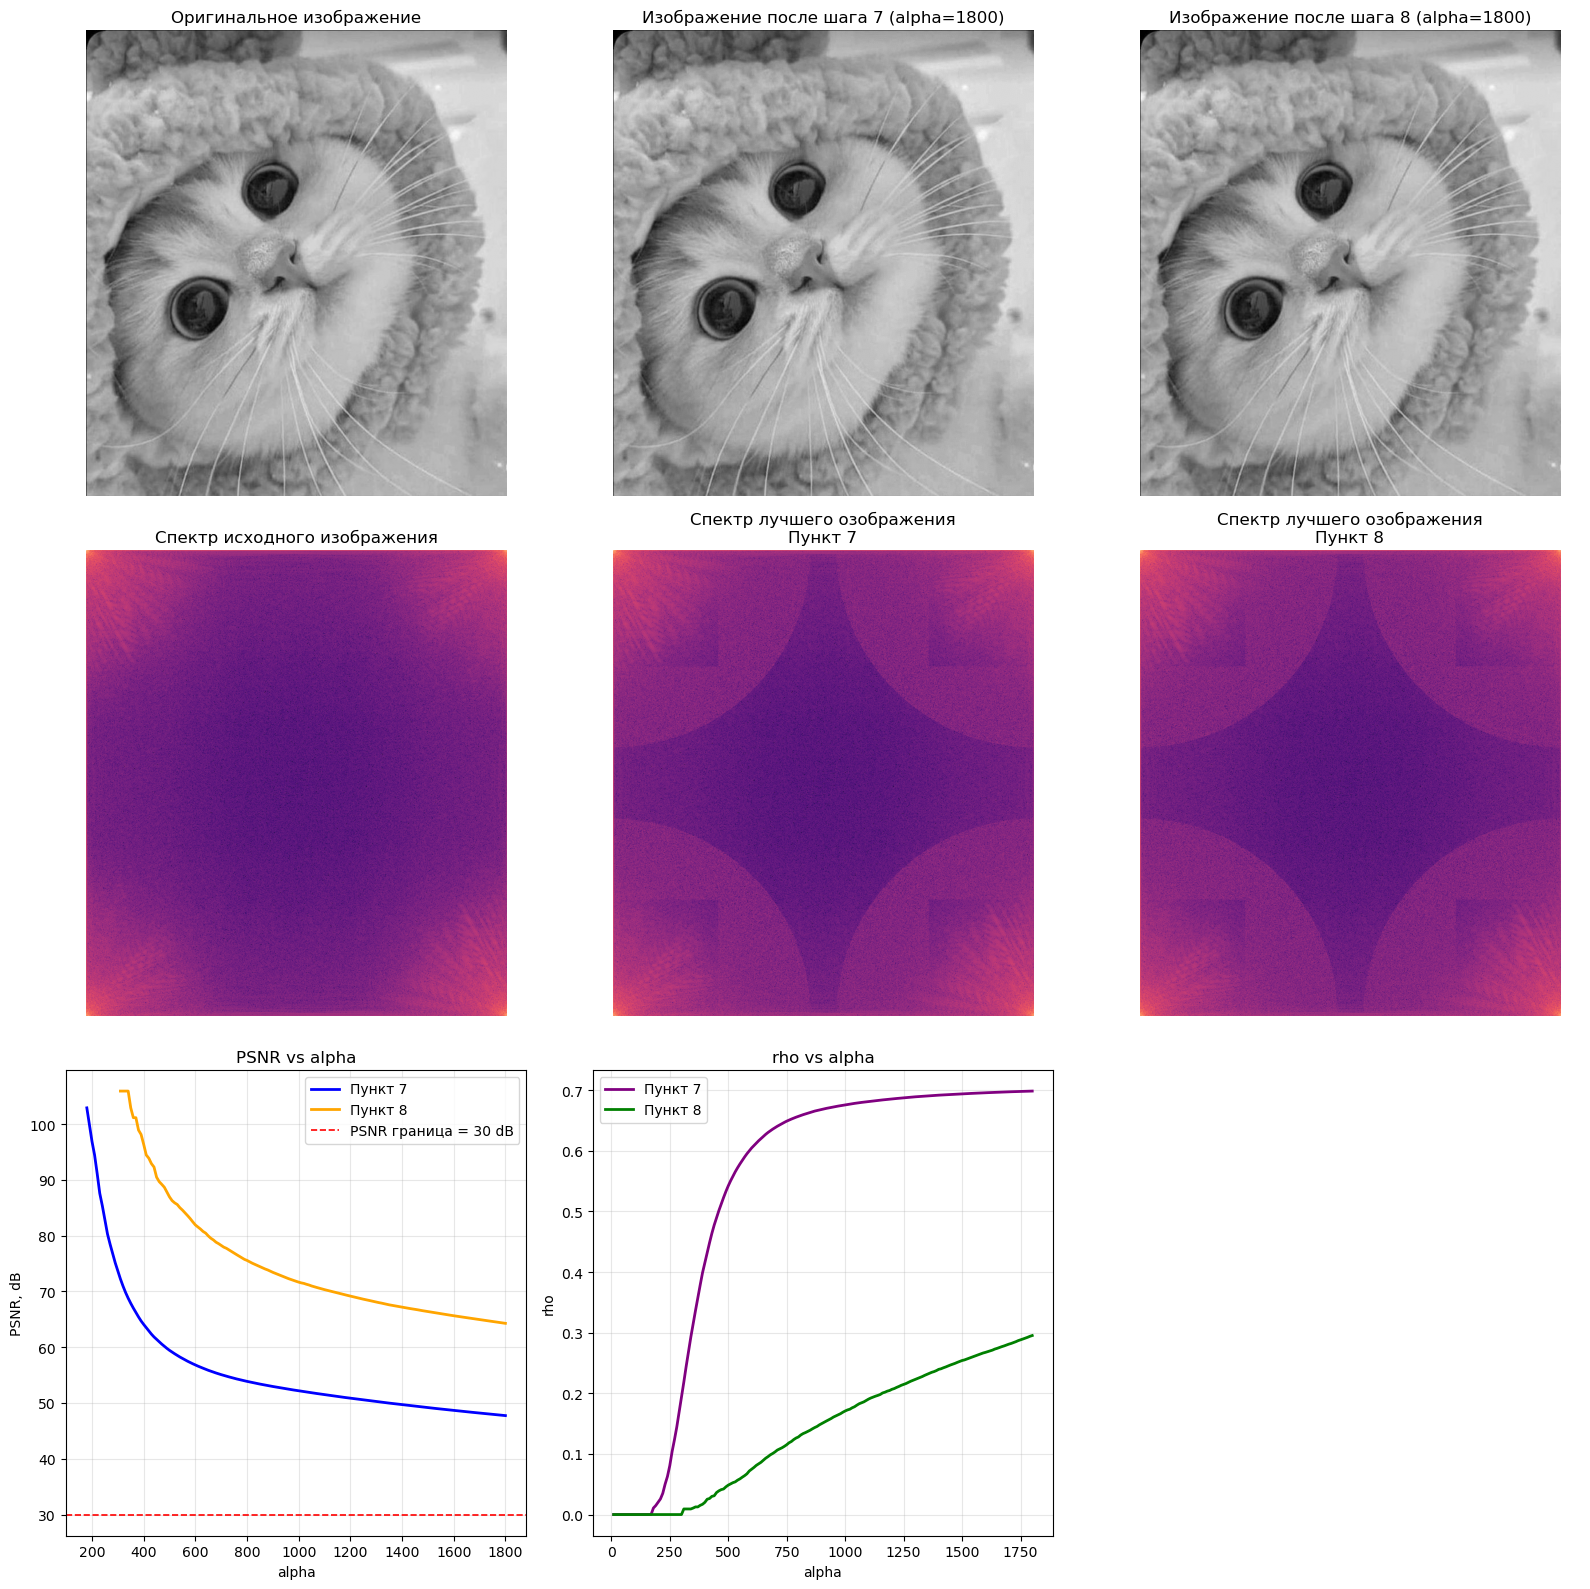

In [292]:
step7_best = {'alpha': alpha_best, 'psnr': psnr_best, 'rho': rho_best}
step8_best = {'alpha': alpha_best8, 'psnr': psnr_best8, 'rho': rho_best8}

print('Лучшие результаты шага 7:')
print(f"\talpha = {step7_best['alpha']:.1f}")
print(f"\tPSNR  = {step7_best['psnr']:.3f} dB")
print(f"\trho   = {step7_best['rho']:.6f}")
print('')
print('Лучшие результаты шага 8 (Beta-MSE):')
print(f"\talpha = {step8_best['alpha']:.1f}")
print(f"\tPSNR  = {step8_best['psnr']:.3f} dB")
print(f"\trho   = {step8_best['rho']:.6f}")

# Resolve best images for Step 7 and Step 8
img_step7 = best['carrier_uint8']
img_step8 = best_beta8['carrier_uint8']

# Curves for Step 7 and Step 8
alphas7 = np.array([r['alpha'] for r in results], dtype=np.float64)
psnr7 = np.array([r['psnr'] for r in results], dtype=np.float64)
rho7 = np.array([r['rho'] for r in results], dtype=np.float64)

alphas8 = np.array([r['alpha'] for r in beta_stats8], dtype=np.float64)
psnr8 = np.array([r['psnr'] for r in beta_stats8], dtype=np.float64)
rho8 = np.array([r['rho'] for r in beta_stats8], dtype=np.float64)

fig, ax = plt.subplots(3, 3, figsize=(16, 16))

ax[0, 0].imshow(container, cmap='gray')
ax[0, 0].set_title('Оригинальное изображение')
ax[0, 0].axis('off')

ax[0, 1].imshow(img_step7, cmap='gray')
ax[0, 1].set_title(f"Изображение после шага 7 (alpha={step7_best['alpha']:.0f})")
ax[0, 1].axis('off')

ax[0, 2].imshow(img_step8, cmap='gray')
ax[0, 2].set_title(f"Изображение после шага 8 (alpha={step8_best['alpha']:.0f})")
ax[0, 2].axis('off')

ax[1, 0].imshow(spec_before, cmap='magma')
ax[1, 0].set_title('Спектр исходного изображения')
ax[1, 0].axis('off')

ax[1, 1].imshow(spec_best, cmap='magma')
ax[1, 1].set_title('Спектр лучшего озображения\nПункт 7')
ax[1, 1].axis('off')

ax[1, 2].imshow(spec_best8, cmap='magma')
ax[1, 2].set_title('Спектр лучшего озображения\nПункт 8')
ax[1, 2].axis('off')

ax[2, 0].plot(alphas7, psnr7, color='blue', lw=2, label='Пункт 7')
ax[2, 0].plot(alphas8, psnr8, color='orange', lw=2, label='Пункт 8')
ax[2, 0].axhline(30.0, color='red', ls='--', lw=1.2, label='PSNR граница = 30 dB')
ax[2, 0].set_title('PSNR vs alpha')
ax[2, 0].set_xlabel('alpha')
ax[2, 0].set_ylabel('PSNR, dB')
ax[2, 0].grid(alpha=0.3)
ax[2, 0].legend(loc='best')

ax[2, 1].plot(alphas7, rho7, color='purple', lw=2, label='Пункт 7')
ax[2, 1].plot(alphas8, rho8, color='green', lw=2, label='Пункт 8')
ax[2, 1].set_title('rho vs alpha')
ax[2, 1].set_xlabel('alpha')
ax[2, 1].set_ylabel('rho')
ax[2, 1].grid(alpha=0.3)
ax[2, 1].legend(loc='best')

ax[2, 2].axis('off')

plt.tight_layout()
plt.show()
